<a href="https://colab.research.google.com/github/ariba8001-maker/Supervise-Machine-Learning-Model-/blob/main/kNN_algorithm(online_fruad).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
# Fraud Detection Project using KNN (Scikit-Learn)

## Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [21]:
import pandas as pd

df = pd.read_csv("/content/onlinefraud.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [47]:
df.head()

df.shape

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42270 entries, 0 to 42269
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            42270 non-null  int64  
 1   type            42270 non-null  int64  
 2   amount          42270 non-null  float64
 3   nameOrig        42270 non-null  int64  
 4   oldbalanceOrg   42270 non-null  float64
 5   newbalanceOrig  42270 non-null  float64
 6   nameDest        42270 non-null  int64  
 7   oldbalanceDest  42270 non-null  float64
 8   newbalanceDest  42270 non-null  float64
 9   isFraud         42270 non-null  int64  
 10  isFlaggedFraud  42270 non-null  float64
dtypes: float64(6), int64(5)
memory usage: 3.9 MB


In [23]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,1
newbalanceDest,1
isFraud,1


In [24]:
 df.duplicated().sum()

np.int64(0)

In [25]:
# Convert 'isFraud' to numeric, coercing any non-numeric values to NaN
df['isFraud'] = pd.to_numeric(df['isFraud'], errors='coerce')

# Drop rows where 'isFraud' is NaN (these are the original NaNs and any values that couldn't be converted to numeric)
df.dropna(subset=['isFraud'], inplace=True)

# Convert to integer (now it's safe as all values are numeric floats)
df['isFraud'] = df['isFraud'].astype(int)

print(df['isFraud'].value_counts())

isFraud
0    42176
1       94
Name: count, dtype: int64


In [26]:
from sklearn.preprocessing import LabelEncoder

#encoding
le = LabelEncoder()

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print(df.head())

   step  type    amount  nameOrig  oldbalanceOrg  newbalanceOrig  nameDest  \
0     1     3   9839.64      4925       170136.0       160296.36     14933   
1     1     3   1864.28     14492        21249.0        19384.72     15557   
2     1     4    181.00      6538          181.0            0.00      4059   
3     1     1    181.00     38737          181.0            0.00      3611   
4     1     3  11668.14     22834        41554.0        29885.86      7454   

   oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0             0.0             0.0        0             0.0  
1             0.0             0.0        0             0.0  
2             0.0             0.0        1             0.0  
3         21182.0             0.0        1             0.0  
4             0.0             0.0        0             0.0  


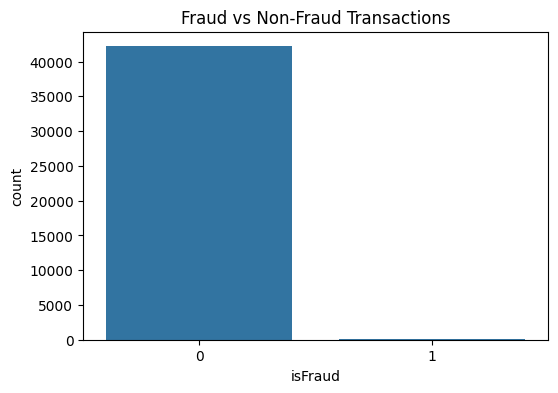

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='isFraud', data=df)
plt.title('Fraud vs Non-Fraud Transactions')
plt.show()

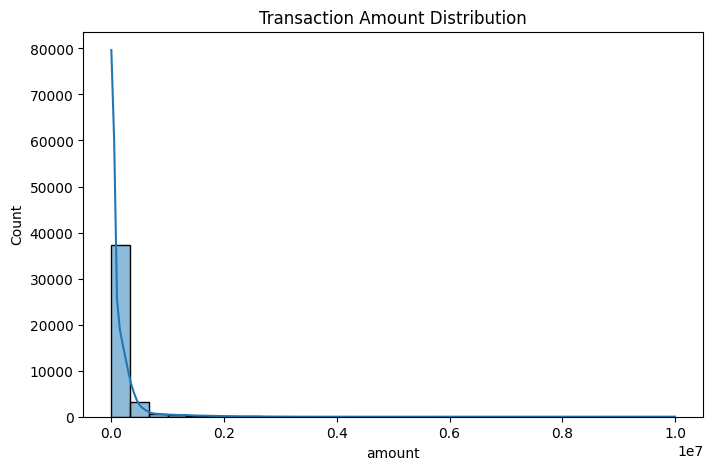

In [28]:

plt.figure(figsize=(8,5))
sns.histplot(df['amount'], bins=30, kde=True)
plt.title('Transaction Amount Distribution')
plt.show()

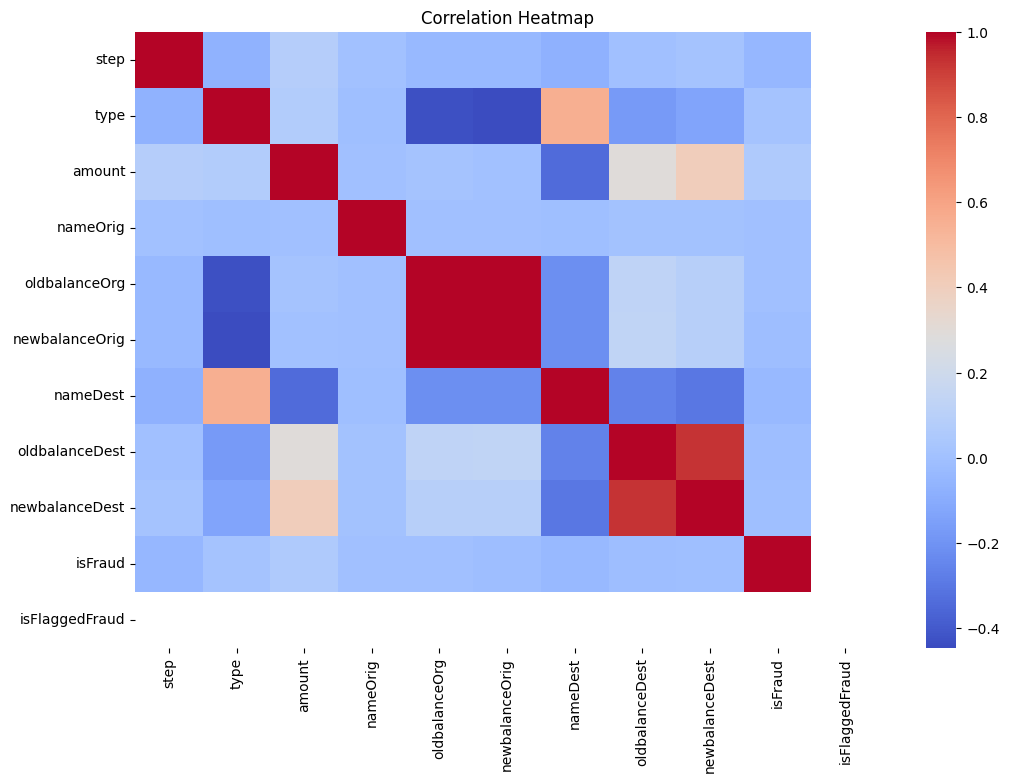

In [52]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [32]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
# Apply KNN Algorithm

# Using K-Nearest Neighbors from ["software","scikit-learn","Python machine learning library"]
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [38]:
y_pred = knn.predict(X_test)

In [40]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9973976815708541


In [41]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[8430    0]
 [  22    2]]


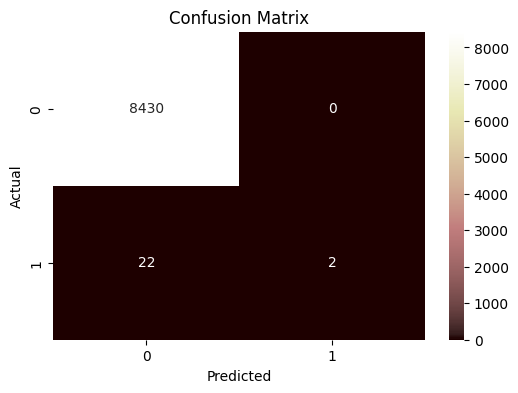

In [45]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='pink')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()